---
title: "Économétrie Financière"
author: "Fiche TP #1"
subtitle: "Données financières et faits stylisés sur données réelles"
format: pdf
---



*S'appuie sur le chapitre 1 (`01-Slides/CM1-donnees-faits-stylises.qmd`).
Les faits stylisés observés ici motivent directement les modèles GARCH
du chapitre 3 (TP3).*


# Avant de commencer

**Langage.** `R` ou `Python`, au choix. Les fonctions équivalentes sont dans
`03-TP/correspondance-R-python.md`. Les corrigés existent dans les deux
langages, déposés après la séance.

**Package clé.** `R` : `quantmod`, pour l'import des données (`getSymbols`,
`dailyReturn`) ; `moments` pour skewness/kurtosis ; `tseries` pour le
test de Jarque-Bera. `Python` : `yfinance` pour l'import ; `scipy.stats`
pour skewness/kurtosis ; `statsmodels.stats.stattools.jarque_bera` pour le
test de normalité.

**Données.** Indice CAC40 (`^FCHI`) ou toute autre action/indice de
votre choix, prix de clôture ajustés, sur au moins 5 ans d'historique
journalier.

In [2]:
#| label: install library python
# a ne lancer qu'une fois, que si les librairies ne sont pas installées
%pip install numpy pandas matplotlib scipy statsmodels openpyxl

Note: you may need to restart the kernel to use updated packages.


In [21]:
#| label: import library python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 6)

# Exercice 1 — Prix, rendements simples et log-rendements

(a) Téléchargez les prix de clôture ajustés de votre actif
    (`quantmod::getSymbols`) sur les 5 dernières années.


In [17]:
#| label: import data
NVDA = yf.download("NVDA", start='2010-01-01', end='2024-06-01', auto_adjust=True)
NVDAprices = NVDA["Close"]

[*********************100%***********************]  1 of 1 completed




(b) Calculez le rendement simple et le log-rendement journaliers
    (`quantmod::dailyReturn`, arguments `type = "arithmetic"` et
    `type = "log"`). Tracez les deux séries sur le même graphique : sont
    -elles visuellement distinguables ?


In [18]:
NVDAreturns = NVDAprices.pct_change().dropna()*100
NVDAreturnsLog = np.log(NVDAprices).diff().dropna()*100

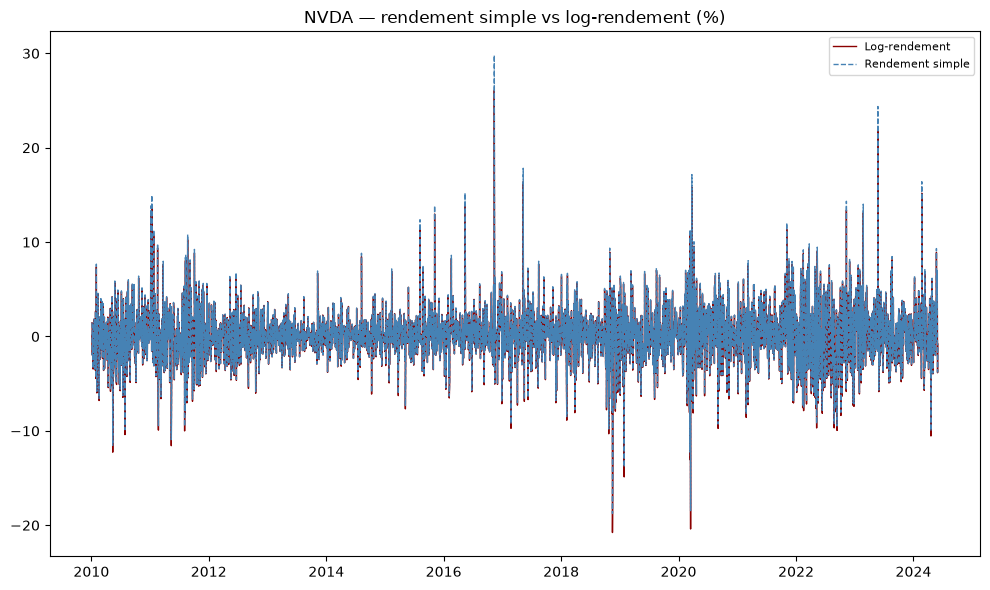

In [20]:
fig, ax = plt.subplots()
ax.plot(NVDAreturnsLog, color="darkred", lw=1, label="Log-rendement")
ax.plot(NVDAreturns, color="steelblue", lw=1, ls="--", label="Rendement simple")
ax.set_title("NVDA — rendement simple vs log-rendement (%)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

(c) Calculez, pour chaque série de rendements, l'écart maximal en valeur
    absolue entre rendement simple et log-rendement sur tout
    l'échantillon. À quel type de journée (forte ou faible variation)
    correspond ce maximum ? Est-ce cohérent avec l'approximation
    $R_t \simeq \tilde R_t$ vue en cours ?

In [22]:
# Écart absolu entre rendement simple et log-rendement
ecarts = (NVDAreturns.iloc[:, 0] - NVDAreturnsLog.iloc[:, 0]).abs()

date_max = ecarts.idxmax()
ecart_max = ecarts.loc[date_max]

print(f"Écart maximal absolu : {ecart_max:.4f} point de pourcentage")
print(f"Date correspondante : {date_max.date()}")
print(f"Rendement simple : {NVDAreturns.loc[date_max].iloc[0]:.4f} %")
print(f"Log-rendement : {NVDAreturnsLog.loc[date_max].iloc[0]:.4f} %")

print(
    "\nLe maximum correspond à une forte variation journalière. "
    "L'approximation R_t ≃ log(1 + R_t) est donc surtout valable "
    "pour les faibles variations."
)

Écart maximal absolu : 3.7191 point de pourcentage
Date correspondante : 2016-11-11
Rendement simple : 29.8067 %
Log-rendement : 26.0876 %

Le maximum correspond à une forte variation journalière. L'approximation R_t ≃ log(1 + R_t) est donc surtout valable pour les faibles variations.



---

# Exercice 2 — Prix vs rendements : stationnarité visuelle

(a) Tracez le prix, puis le log-rendement, l'un au-dessus de l'autre.
(b) Sur quelle série la moyenne semble-t-elle constante dans le temps ?
    Sur laquelle une tendance ou des ruptures de niveau sont-elles
    visibles ?
(c) Reliez votre observation au fait stylisé 1 du cours.

---

# Exercice 3 — Statistiques descriptives et test de normalité

(a) Calculez moyenne, écart-type, asymétrie et kurtosis des
    log-rendements (`moments::skewness`, `moments::kurtosis`).
(b) Comparez la kurtosis obtenue à la valeur de référence sous
    normalité. La distribution est-elle leptokurtique ?
(c) Testez formellement $H_0: K(R_t)=3$ (à la main, comme au TD1) puis
    la normalité conjointe par un test de Jarque-Bera
    (`tseries::jarque.bera.test`). Les deux concluent-elles dans le même
    sens ?
(d) Tracez un histogramme des rendements avec la densité normale
    ajustée superposée, puis un QQ-plot (`qqnorm`, `qqline`). Commentez.

---

# Exercice 4 — Absence d'autocorrélation des rendements

(a) Tracez l'ACF et la PACF des log-rendements sur 20 retards
    (`acf`, `pacf`).
(b) Appliquez un test de Ljung-Box (`Box.test(..., type = "Ljung-Box")`)
    à l'ordre 10. Concluez sur la présence d'autocorrélation linéaire.
(c) Ce résultat signifie-t-il que les rendements sont indépendants dans
    le temps ? Justifiez en anticipant sur l'exercice suivant.

---

# Exercice 5 — Clustering de volatilité et effet ARCH

(a) Tracez les rendements au carré (ou en valeur absolue) en fonction du
    temps. Observez-vous des périodes de forte et de faible amplitude
    regroupées dans le temps ?
(b) Tracez l'ACF des rendements **au carré** sur 20 retards, et
    appliquez le test de Ljung-Box (ordre 10) à cette série.
(c) Comparez ce résultat à celui de l'exercice 4. Quel est le nom donné
    à ce phénomène dans le cours, et quel chapitre le modélise
    explicitement ?

---

# Exercice 6 — Asymétrie et effet de levier (aperçu)

(a) Séparez l'échantillon de rendements en deux sous-périodes : une
    période "calme" et une période incluant un épisode de forte baisse
    (une crise, par exemple 2020 pour la plupart des indices).
    Comparez l'écart-type des rendements sur les deux sous-périodes.
(b) Calculez la corrélation entre le rendement du jour $R_t$ et la
    variation de volatilité réalisée du lendemain (approximée par
    $|R_{t+1}|$ ou $R_{t+1}^2$). Le signe obtenu est-il cohérent avec
    l'effet de levier décrit en cours ?
(c) Ce dernier point est repris et formalisé au chapitre 3 (modèles
    EGARCH et GJR-GARCH) — retenez simplement l'observation empirique
    pour l'instant.

---

# Exercice 7 — Sur votre propre actif (préparation du projet)

Recommencez les exercices 3 à 5 sur un autre actif de votre choix
(action, autre indice, crypto-actif). Les faits stylisés observés
sont-ils aussi marqués ? Gardez ce code : il servira de point de départ
pour la partie "faits stylisés" de votre projet.